# Random Forest Modeling

Train and evaluate a Random Forest classifier to predict nucleotide changes in DENV genome regions (E, 5′UTR, 3′UTR) using environmental data (temperature, CO₂), as part of a comparative study for climate-aware viral evolution forecasting.

### Import required libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix, f1_score)

import joblib

### Load processed data

In [2]:
df = pd.read_csv('../data/processed_genomic_dataset.csv')
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (359, 2017)


,Avg_Temp_C,CO2_Emission_Mt,p_1,p_2,p_3,p_4,p_5,p_6,p_7,p_8,...,p_2006,p_2007,p_2008,p_2009,p_2010,p_2011,p_2012,p_2013,p_2014,p_2015
0,26.16,2489.9,4,4,3,1,4,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
2,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
3,26.16,2489.9,3,1,4,1,1,3,1,1,...,0,0,0,0,0,0,0,0,0,0
4,26.16,2489.9,4,3,2,3,3,1,4,4,...,0,0,0,0,0,0,0,0,0,0


### Define features and targets (X & y)

In [3]:
feature_cols = df.columns[:2]        
target_cols = df.columns[2:]         

X = df[feature_cols]
y = df[target_cols]

print("Shape of X (features):", X.shape)
print("Shape of y (targets):", y.shape)

Shape of X (features): (359, 2)
Shape of y (targets): (359, 2015)


### Train-Test Split

In [4]:
# 70% train, 30% test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42,
)

print("Train set size:", X_train.shape[0])
print("Test set size:", X_test.shape[0])

Train set size: 251
Test set size: 108


### Random Forest Model Training
We use a `MultiOutputClassifier` wrapper to enable simultaneous prediction of all 2015 nucleotide positions.

In [5]:
rf_base = RandomForestClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    n_jobs=-1
)

rf_multi = MultiOutputClassifier(rf_base)
rf_multi.fit(X_train, y_train)

MultiOutputClassifier(estimator=RandomForestClassifier(max_depth=7, n_jobs=-1,
                                                       random_state=42))

**Model Hyperparameter Choices:**

- `n_estimators=100`:  
  Set to 100 trees to provide a balance between model robustness and computational efficiency. Increasing the number of trees can improve stability and accuracy, but also increases computational time. For a small dataset, 100 estimators is a commonly recommended value that delivers consistent performance without excessive overhead.

- `max_depth=7`:  
  Restricted to 7 levels to avoid overfitting on the small dataset (359 samples). Fully grown trees may memorize noise in small datasets, reducing the model’s ability to generalize. Setting an intermediate depth encourages the model to focus on the most predictive features and patterns.

- `random_state=42`:  
  Fixed to ensure that results are reproducible. Using a constant seed value makes experiments consistent and model performance comparable across multiple runs or with different algorithms.

- `n_jobs=-1`:  
  Set to use all available CPU cores for parallel processing. This significantly speeds up model training and prediction, especially with ensemble methods like Random Forests, and is beneficial even on modest hardware.

*Hyperparameter optimization (e.g., grid search for best values) is reserved as a direction for future work, to maintain computational simplicity and focus on core research objectives in this thesis.*


### Model Evaluation

#### Predict on test set

In [6]:
y_pred = rf_multi.predict(X_test)

#### Overall accuracy

In [7]:
overall_accuracy = (y_pred == y_test.values).mean()
print(f"Overall nucleotide-level accuracy: {overall_accuracy:.3f}")

Overall nucleotide-level accuracy: 0.455


*Percentage of all nucleotides predicted correctly across all positions and samples*

#### Per-position accuracy

In [8]:
per_position_accuracy = (y_pred == y_test.values).mean(axis=0)
per_position_df = pd.DataFrame({
    'position': target_cols,
    'accuracy': per_position_accuracy
})
print(per_position_df.head())

  position  accuracy
0      p_1  0.583333
1      p_2  0.462963
2      p_3  0.527778
3      p_4  0.601852
4      p_5  0.583333


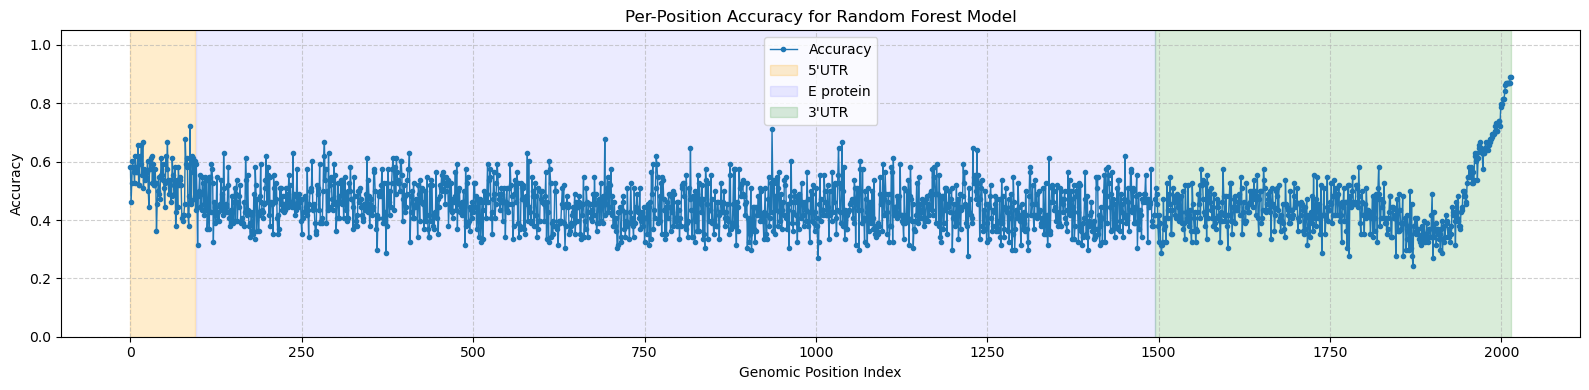

In [9]:
# Plot per-position accuracy with region labels (E, 5′UTR, 3′UTR)
utr5_start, utr5_end = 0, 94       
e_start, e_end = 95, 1494          
utr3_start, utr3_end = 1495, 2014  

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), per_position_accuracy, marker='.', linestyle='-', linewidth=1, label='Accuracy')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per-Position Accuracy for Random Forest Model')
plt.xlabel('Genomic Position Index')
plt.ylabel('Accuracy')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Accuracy for Random Forest Model

The above plot displays the per-position prediction accuracy of the Random Forest model across all nucleotide positions within the concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions of the DENV genome.  
Each data point represents the accuracy of nucleotide prediction at a specific genomic position, while colored background regions correspond to biologically distinct genome segments (5′UTR, E protein, 3′UTR).

#### Key Insights:
- **Overall performance:**  
  The model achieves moderate accuracy across most positions, with values generally ranging between 0.3 and 0.6. This suggests the task is challenging, likely due to the biological diversity and complexity of nucleotide variation in these regions.
- **5′UTR (orange, left):**  
  Accuracy fluctuates but is generally consistent with the central E protein region, with no extreme outliers observed. This indicates that environmental features may provide some predictive power, but the inherent sequence variability limits perfect prediction.
- **Envelope (E) protein (blue, center):**  
  The accuracy remains broadly stable, though some local dips and spikes are evident. This reflects the known evolutionary plasticity and antigenic diversity within the E protein, making certain positions harder to predict.
- **3′UTR (green, right):**  
  There is a distinct upward trend in accuracy toward the very end of the 3′UTR region, where the model achieves its highest per-position accuracy. This likely reflects highly conserved sites or padding.
- **Difficult-to-predict positions:**  
  Several positions throughout the sequence show notably low accuracy, suggesting the presence of mutation hotspots, rare bases, or regions where environmental predictors are less informative.

In [10]:
# Save per-position accuracy
per_position_df.to_csv('../results/rf_per_position_accuracy.csv', index=False)

#### Calculate per-position Classification Report and Confusion Matrix

In [11]:
report_list = []
conf_matrix_list = []

for idx, col in enumerate(target_cols):
    y_true_col = y_test[col]
    y_pred_col = y_pred[:, idx]
    report = classification_report(y_true_col, y_pred_col, output_dict=True, zero_division=0)
    cm = confusion_matrix(y_true_col, y_pred_col)

    # Flattened classification report (main averages and support)
    row = {
        'position': col,
        'macro_f1': report['macro avg']['f1-score'],
        'macro_precision': report['macro avg']['precision'],
        'macro_recall': report['macro avg']['recall'],
        'weighted_f1': report['weighted avg']['f1-score'],
        'weighted_precision': report['weighted avg']['precision'],
        'weighted_recall': report['weighted avg']['recall'],
        'support': report['weighted avg']['support']
    }
    # Per-class F1
    for base in ['0', '1', '2', '3', '4']:  # Adjust base labels as in your data
        if base in report:
            row[f'f1_{base}'] = report[base]['f1-score']
            row[f'precision_{base}'] = report[base]['precision']
            row[f'recall_{base}'] = report[base]['recall']
            row[f'support_{base}'] = report[base]['support']
    report_list.append(row)

    # Confusion matrix as a flattened string (or as a nested list)
    conf_matrix_list.append({
        'position': col,
        'confusion_matrix': cm.tolist()
    })

# Convert lists to DataFrames
report_df = pd.DataFrame(report_list)
conf_matrix_df = pd.DataFrame(conf_matrix_list)

In [12]:
report_df.head()

,position,macro_f1,macro_precision,macro_recall,weighted_f1,weighted_precision,weighted_recall,support,f1_1,precision_1,...,recall_3,support_3,f1_4,precision_4,recall_4,support_4,f1_0,precision_0,recall_0,support_0
0,p_1,0.386225,0.388683,0.386441,0.567439,0.555027,0.583333,108.0,0.713178,0.676471,...,0.458333,24.0,0.000000,0.000000,0.000000,5.0,NaN,NaN,NaN,NaN
1,p_2,0.361598,0.372511,0.398496,0.405655,0.394557,0.462963,108.0,0.602151,0.509091,...,0.571429,28.0,0.387097,0.600000,0.285714,21.0,NaN,NaN,NaN,NaN
2,p_3,0.460420,0.543290,0.454310,0.492743,0.511079,0.527778,108.0,0.533333,0.800000,...,0.090909,22.0,0.639175,0.563636,0.738095,42.0,NaN,NaN,NaN,NaN
3,p_4,0.391375,0.390828,0.400546,0.554395,0.520713,0.601852,108.0,0.444444,0.500000,...,0.000000,14.0,0.352941,0.375000,0.333333,18.0,NaN,NaN,NaN,NaN
4,p_5,0.303182,0.320312,0.325036,0.480844,0.426408,0.583333,108.0,0.000000,0.000000,...,0.936508,63.0,0.470588,0.666667,0.363636,11.0,NaN,NaN,NaN,NaN


In [13]:
conf_matrix_df.head()

,position,confusion_matrix
0,p_1,"[[46, 6, 9, 0], [8, 6, 2, 2], [11, 2, 11, 0], ..."
1,p_2,"[[28, 1, 9, 0], [11, 0, 8, 2], [10, 0, 16, 2],..."
2,p_3,"[[4, 3, 0, 3], [0, 20, 3, 11], [1, 9, 2, 10], ..."
3,p_4,"[[6, 6, 0, 3], [4, 53, 3, 1], [0, 8, 0, 6], [2..."
4,p_5,"[[0, 0, 14, 1], [2, 0, 17, 0], [1, 2, 59, 1], ..."


#### Plot Macro F1 from classification report

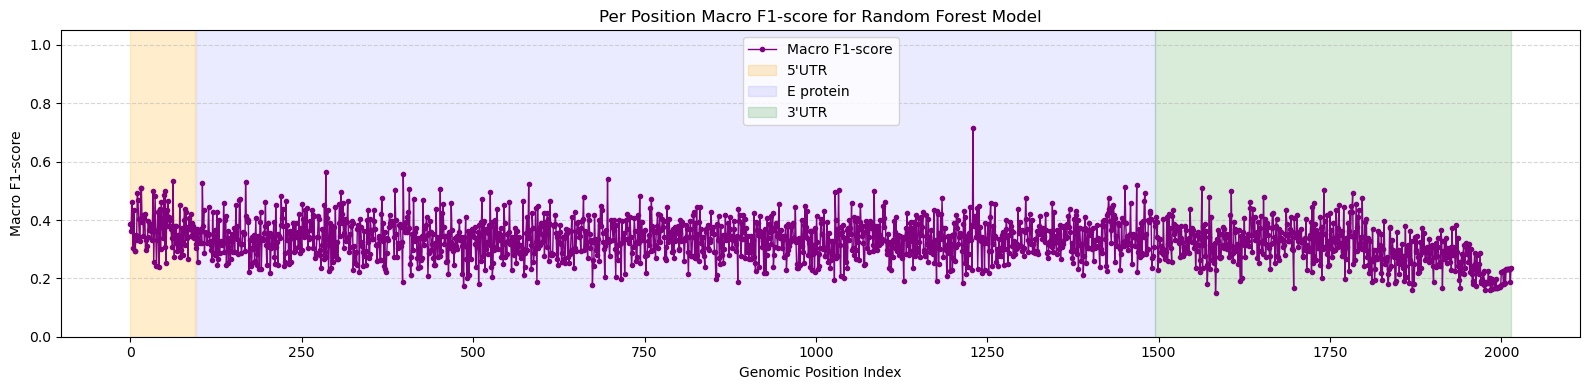

In [15]:
# Extract macro F1 for all positions
positions = report_df['position']
macro_f1 = report_df['macro_f1']

plt.figure(figsize=(16, 4))
plt.plot(range(len(target_cols)), macro_f1, marker='.', linestyle='-', linewidth=1, color='purple', label='Macro F1-score')

# Highlight regions
plt.axvspan(utr5_start, utr5_end, color='orange', alpha=0.2, label="5'UTR")
plt.axvspan(e_start, e_end, color='blue', alpha=0.08, label="E protein")
plt.axvspan(utr3_start, utr3_end, color='green', alpha=0.15, label="3'UTR")

plt.title('Per Position Macro F1-score for Random Forest Model')
plt.xlabel('Genomic Position Index')
plt.ylabel('Macro F1-score')
plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

### Analysis of Per-Position Macro F1-score for Random Forest Model

The above plot illustrates the macro F1-score achieved by the Random Forest model at each nucleotide position across the DENV genome’s concatenated 5′UTR, Envelope (E) protein, and 3′UTR regions.  
The macro F1-score provides a balanced measure of the model’s ability to correctly predict all nucleotide classes at a given position, making it especially valuable for genomic data where class imbalance is common. The colored regions again highlight the biologically distinct segments of the sequence.

#### Key Insights:
- **Overall performance:**  
  The macro F1-scores are generally lower than the corresponding accuracy values, reflecting the difficulty of predicting less frequent nucleotide classes (especially minor bases or rare mutations) compared to dominant ones.
- **5′UTR (orange, left):**  
  Macro F1-scores in the 5′UTR are relatively higher and more consistent than in the downstream regions. This suggests that predictions in this regulatory region are more balanced across different nucleotide classes, potentially due to greater sequence conservation or clearer association with environmental variables.
- **Envelope (E) protein (blue, center):**  
  The central E protein region exhibits broad variability in macro F1, with many positions displaying modest values and occasional sharp dips. This highlights the complexity and high variability typical of the E protein, a region known for its antigenic diversity and evolutionary adaptation.
- **3′UTR (green, right):**  
  There is a noticeable downward trend in macro F1-score towards the end of the 3′UTR, indicating that while some positions are predicted with reasonable class balance, many are dominated by a single base or subject to high uncertainty—possibly due to alignment artifacts or padding.
- **Comparison to accuracy:**  
  Macro F1-score complements the accuracy plot by revealing how well the model predicts minority classes at each site. Some positions with moderate accuracy may still have low macro F1, signaling that correct predictions are driven by a single prevalent base rather than balanced, multi-class performance.

#### Plot Per-Class F1 from classification report

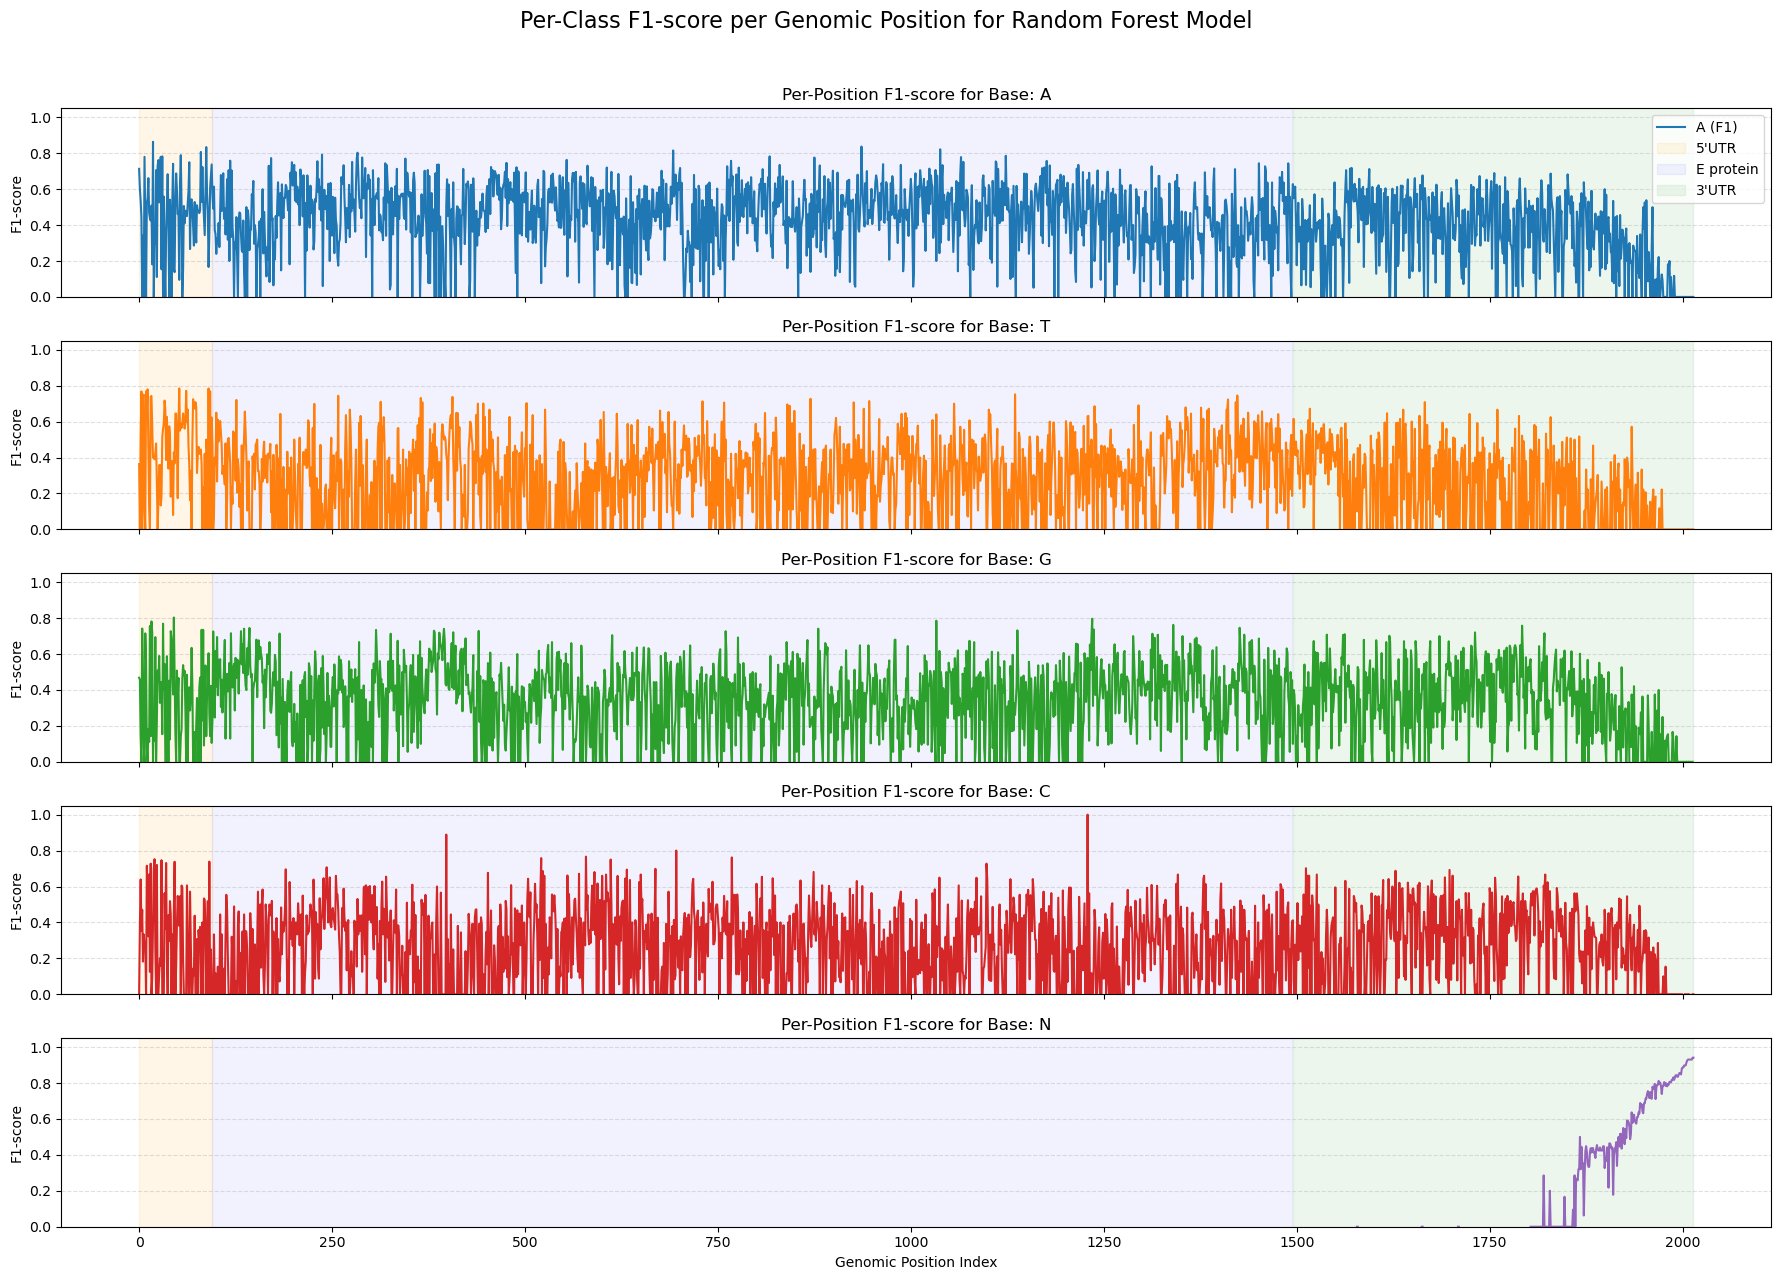

In [16]:
class_labels = {
    '1': 'A',
    '2': 'T',
    '3': 'G',
    '4': 'C',
    '0': 'N'
}
class_keys = ['1','2','3','4','0']
f1_matrix = report_df[[f'f1_{key}' for key in class_keys]].values

n_classes = len(class_keys)
fig, axes = plt.subplots(n_classes, 1, figsize=(18, 2.5 * n_classes), sharex=True, sharey=True)

for idx, key in enumerate(class_keys):
    ax = axes[idx]
    ax.plot(range(len(report_df)), f1_matrix[:, idx], label=f"{class_labels[key]} (F1)", color='C'+str(idx))
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.05)
    ax.set_title(f"Per-Position F1-score for Base: {class_labels[key]}")
    ax.grid(axis='y', linestyle='--', alpha=0.4)

    ax.axvspan(utr5_start, utr5_end, color='orange', alpha=0.09, label="5'UTR" if idx==0 else None)
    ax.axvspan(e_start, e_end, color='blue', alpha=0.05, label="E protein" if idx==0 else None)
    ax.axvspan(utr3_start, utr3_end, color='green', alpha=0.07, label="3'UTR" if idx==0 else None)
    if idx == 0:
        ax.legend(loc='upper right')

axes[-1].set_xlabel("Genomic Position Index")
plt.suptitle("Per-Class F1-score per Genomic Position for Random Forest Model", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Analysis of Per-Class F1-score per Genomic Position for Random Forest Model

The above figure presents the per-position F1-score for each nucleotide class (A, T, G, C, N) across the entire sequence of interest, divided by genomic region (5′UTR, Envelope E protein, and 3′UTR). Each subplot corresponds to one nucleotide base and visualizes how well the Random Forest model predicts that base at every genomic position.

#### Key Insights:
- **Base A:**  
  The model achieves consistently high F1-scores for base A across most positions, especially within the 5′UTR and E protein regions. This indicates a strong predictive ability for A, possibly due to its higher frequency or more stable context in these regions. A gradual decline is observed towards the end of the 3′UTR possibly due to padding.
- **Base T:**  
  F1-scores for T are moderate but slightly more variable than for A, with some positions showing clear dips. This suggests T is predicted reasonably well but with greater position-specific uncertainty, possibly reflecting biological or model limitations.
- **Base G:**  
  The model’s performance for G is comparable to T but with more frequent local drops and a pronounced decrease in the distal 3′UTR region. The higher variability here may be due to rare occurrences of G or increased mutation rates at certain sites.
- **Base C:**  
  Prediction of C is generally weaker and more erratic across all regions, with numerous positions showing low F1-scores. This suggests that C is either a minor base at many positions or presents unique challenges for the model, possibly due to biological constraints or insufficient data.
- **Base N (unknown/padding):**  
  High F1-scores for N are primarily confined to the end of the sequence (late 3′UTR), aligning with the padding introduced during preprocessing for shorter sequences. This confirms the model’s ability to correctly identify padding/unknown positions but also highlights that this class is not relevant across the entire sequence.

#### Regional Trends:
- **5′UTR:**  
  Most bases are predicted with higher and more stable F1-scores, especially for A and G, indicating greater sequence conservation and model confidence.
- **E protein:**  
  All bases exhibit broad variability, with certain stretches showing consistently lower F1-scores for minor bases (C, G), reflecting the region’s known evolutionary plasticity and genetic diversity.
- **3′UTR:**  
  F1-scores for all standard bases decline markedly towards the sequence end, while N increases, indicating increasing alignment uncertainty or prevalence of padding.

#### Heatmap for Confusion Matrix

In [17]:
# Merge to associate macro_f1 with each confusion matrix
merged_df = pd.merge(report_df[['position', 'macro_f1']], conf_matrix_df, on='position')

base_labels = ['N', 'A', 'T', 'G', 'C']

def plot_conf_matrices_grid(df, positions, base_labels, fig_title):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    axes = axes.flatten()
    for idx, pos in enumerate(positions):
        cm = np.array(df[df['position'] == pos]['confusion_matrix'].values[0])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                    xticklabels=base_labels, yticklabels=base_labels, 
                    ax=axes[idx], cbar=False)
        axes[idx].set_title(f"{pos}")
        axes[idx].set_xlabel('Predicted')
        axes[idx].set_ylabel('True')
    # Hide any unused subplots (if less than 10)
    for i in range(len(positions), 10):
        axes[i].axis('off')
    plt.suptitle(fig_title, fontsize=20, y=1.03)
    plt.tight_layout()
    plt.show()

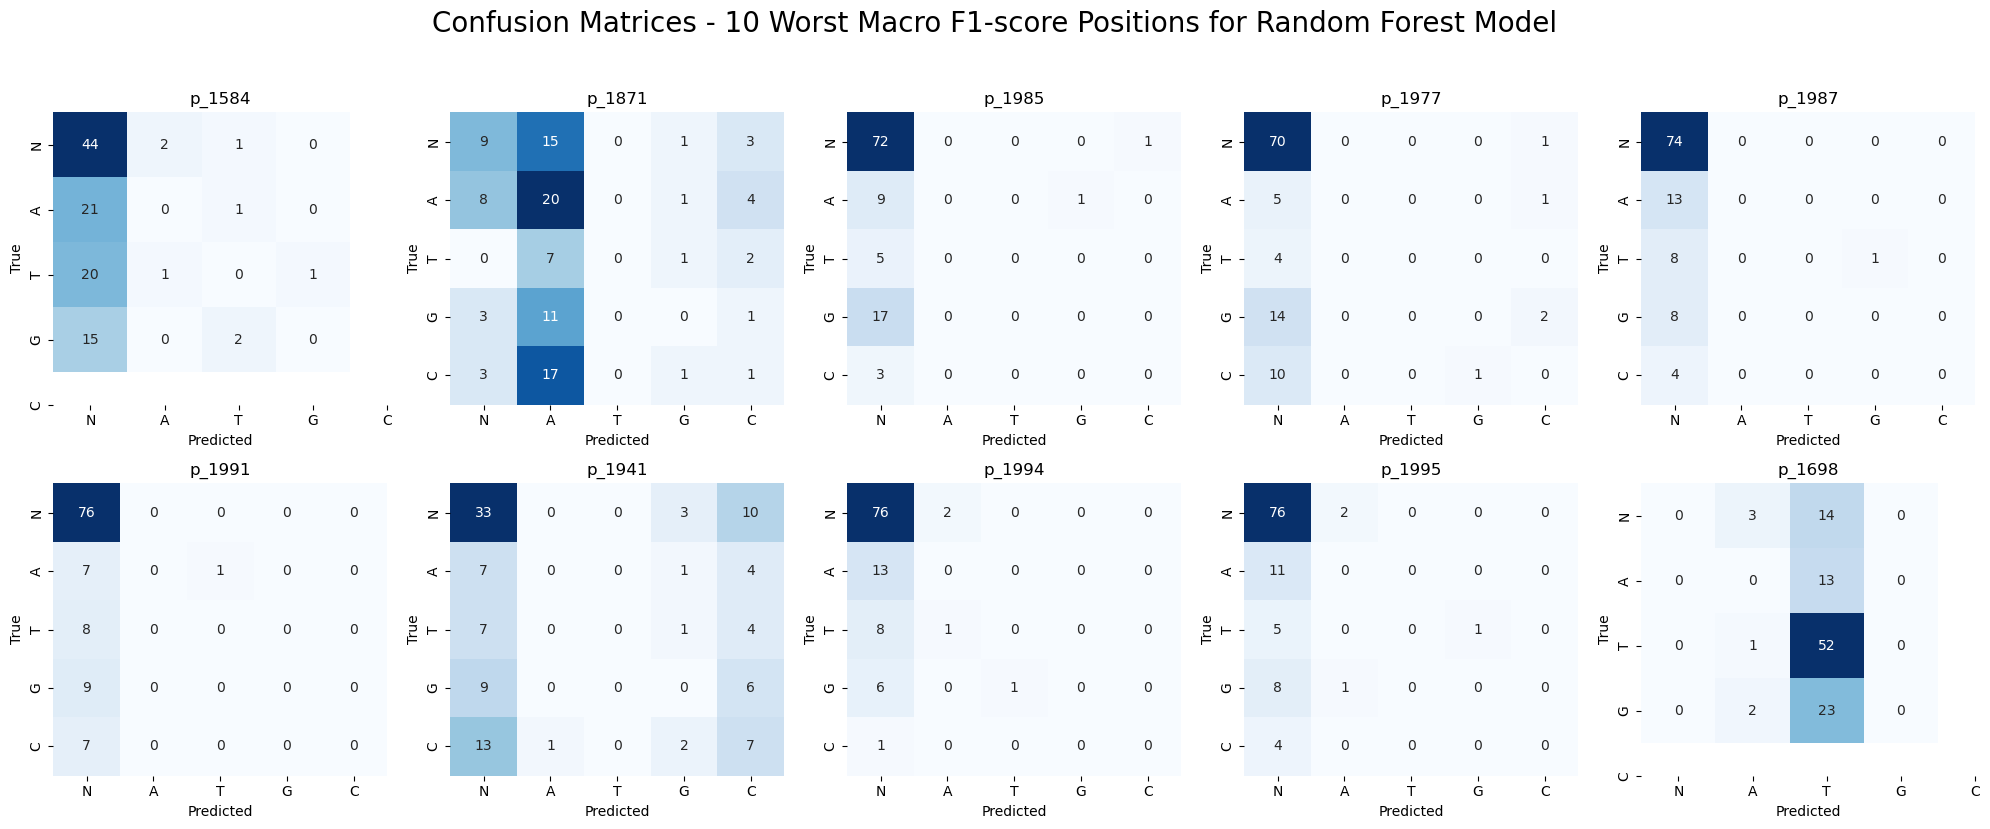

In [18]:
# 10 worst F1-score positions
worst_10 = merged_df.nsmallest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, worst_10, base_labels, "Confusion Matrices - 10 Worst Macro F1-score Positions for Random Forest Model")

### Analysis of Confusion Matrices at the 10 Worst Macro F1-score Positions

The figure above shows the confusion matrices for the 10 nucleotide positions where the Random Forest model achieved the lowest macro F1-scores. Each heatmap represents the model’s predictions at a single genomic position, with true nucleotides on the y-axis and predicted nucleotides on the x-axis (classes: N, A, T, G, C).

#### Key Insights:
- **High Misclassification and Dominance by One Class:**  
  Many confusion matrices show a strong diagonal only for the "N" (unknown/padding) class, with frequent misclassification of true A, T, G, or C bases as "N." This suggests the model has difficulty distinguishing genuine nucleotide types at these positions and tends to default to the most common or ambiguous label.
- **Rare or Absent Minor Bases:**  
  Several positions display entire rows or columns of zeros for some classes, indicating that certain bases are either extremely rare or never correctly predicted at these sites. For example, positions with all predictions concentrated in the "N" column imply the model is unable to identify actual variation.
- **Ambiguity and Lack of Signal:**  
  Off-diagonal entries—where true bases are systematically predicted as another class—indicate confusion in base calling. For some matrices, non-"N" true bases are scattered across predictions, reflecting low confidence and possibly insufficient information from environmental predictors or high biological variability.
- **Possible Sequence End/Padding Effects:**  
  Positions dominated by "N" likely correspond to the ends of the sequence, where padding or alignment gaps are common after sequence normalization, explaining the model’s certainty in predicting "N" but inability to distinguish true nucleotides.

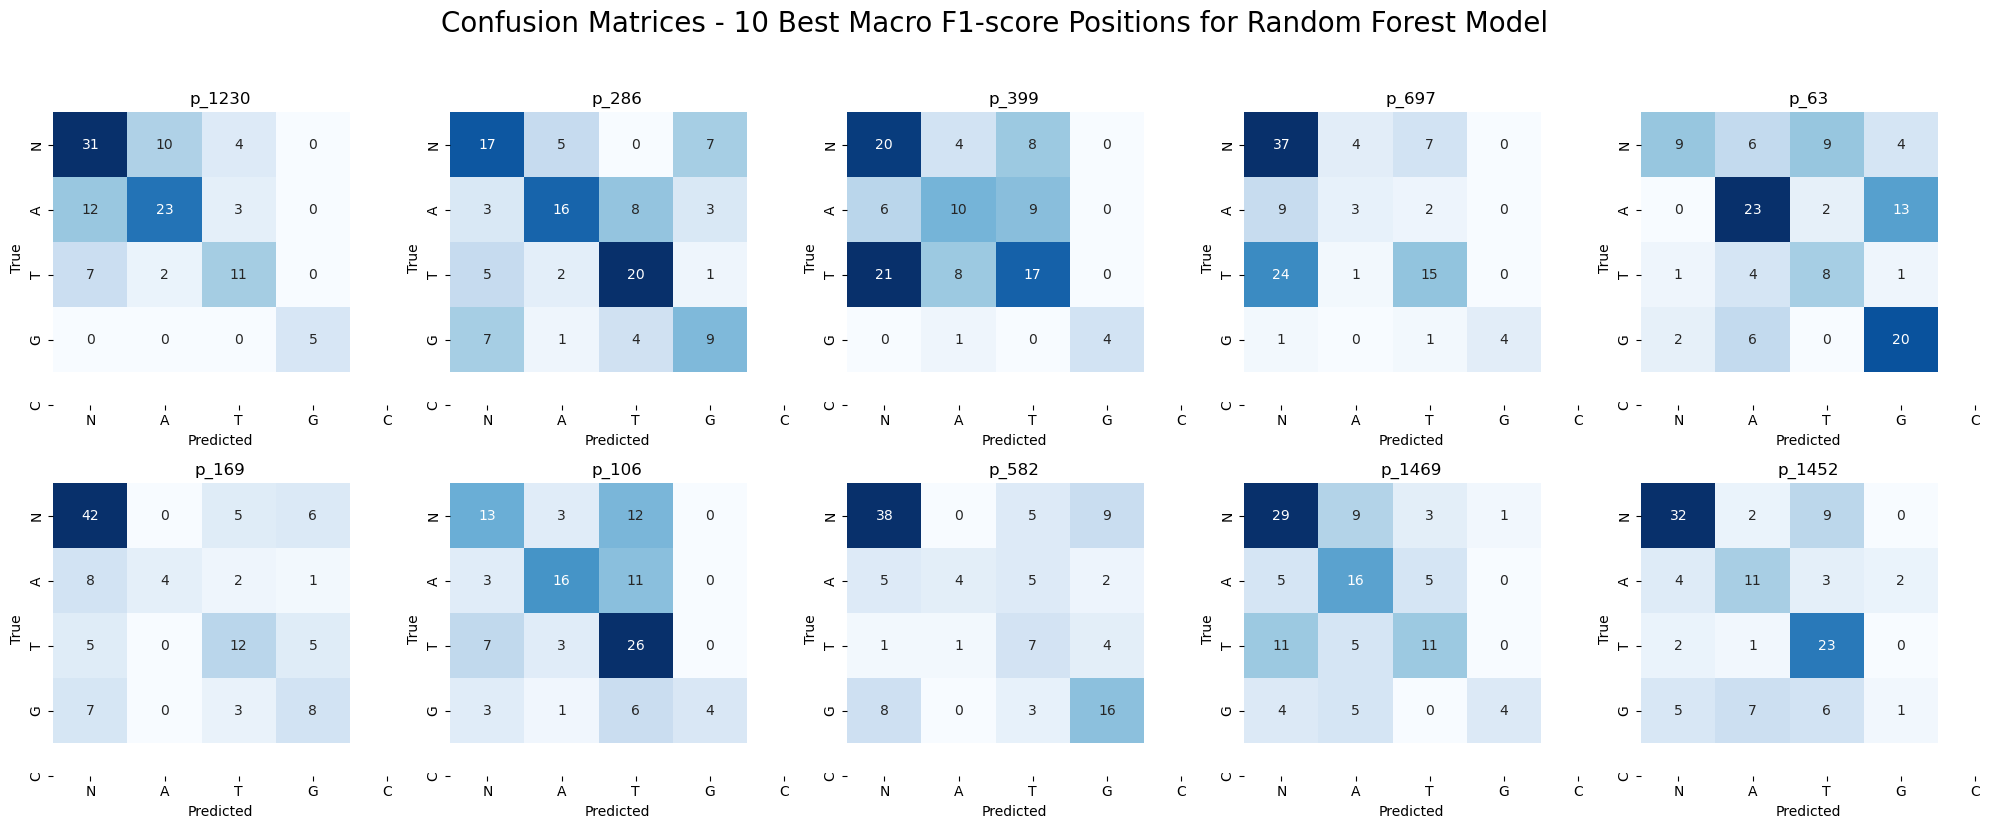

In [19]:
# 10 best F1-score positions
best_10 = merged_df.nlargest(10, 'macro_f1')['position'].tolist()
plot_conf_matrices_grid(merged_df, best_10, base_labels, "Confusion Matrices - 10 Best Macro F1-score Positions for Random Forest Model")

### Analysis of Confusion Matrices at the 10 Best Macro F1-score Positions

The above figure displays the confusion matrices for the 10 genomic positions where the Random Forest model achieved the highest macro F1-scores. Each matrix summarizes the agreement between true and predicted nucleotide classes (N, A, T, G, C) at a specific position, providing a detailed breakdown of model performance in these best-case scenarios.

#### Key Insights:
- **Strong Diagonal Patterns:**  
  Most matrices show a prominent diagonal structure, indicating that the majority of true nucleotide classes are being correctly predicted by the model at these positions. This reflects high specificity and sensitivity for multiple bases at once—a hallmark of balanced and reliable model predictions.
- **Effective Multi-class Prediction:**  
  Unlike the worst-performing positions, these matrices reveal the model’s ability to distinguish between all nucleotide classes, not just the dominant or most frequent one. Off-diagonal entries are generally low, signifying minimal confusion among classes.
- **Prediction Beyond Dominant Class:**  
  In several positions, even minority bases (such as G or C) are predicted with substantial accuracy, as shown by clear non-zero counts on the diagonal for these classes. This demonstrates the model’s capacity to identify less common mutations or base calls when sufficient data and signal are available.
- **Reduced Ambiguity and Padding Effects:**  
  The proportion of true nucleotides classified as "N" (unknown/padding) is much lower in these matrices compared to the worst-performing positions, indicating confident discrimination of biologically meaningful bases.

In [20]:
# Save to CSV (or JSON for confusion matrices)
report_df.to_csv('../results/rf_per_position_classification_report.csv', index=False)
conf_matrix_df.to_json('../results/rf_per_position_confusion_matrices.json', orient='records')

### Save the model

In [21]:
joblib.dump(rf_multi, '../models/rf_multioutput_model.joblib')

['../models/rf_multioutput_model.joblib']